## Objective: 
### Estimate the medical insurance claim amount based on personal data.

## Import Libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


## Load the Dataset

In [ ]:
# Load CSV file
data = pd.read_csv("insurance.csv")  

# Check structure
print(data.shape)
print(data.columns)
print(data.head())
print(data.info())
print(data.isnull().sum())  # check for missing values


(1332, 11)
Index(['index', 'PatientID', 'age', 'gender', 'bmi', 'bloodpressure',
       'diabetic', 'children', 'smoker', 'region', 'claim'],
      dtype='object')
   index  PatientID  age gender   bmi  bloodpressure diabetic  children  \
0      0          1   39   Male  23.2             91      Yes         0   
1      1          2   24   Male  30.1             87       No         0   
2      7          8   19   Male  41.1            100       No         0   
3      8          9   20   Male  43.0             86       No         0   
4      9         10   30   Male  53.1             97       No         0   

  smoker     region    claim  
0     No  southeast  1121.87  
1     No  southeast  1131.51  
2     No  northwest  1146.80  
3     No  northwest  1149.40  
4     No  northwest  1163.46  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1332 entries, 0 to 1331
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0  

## Visualize Data and Correlations

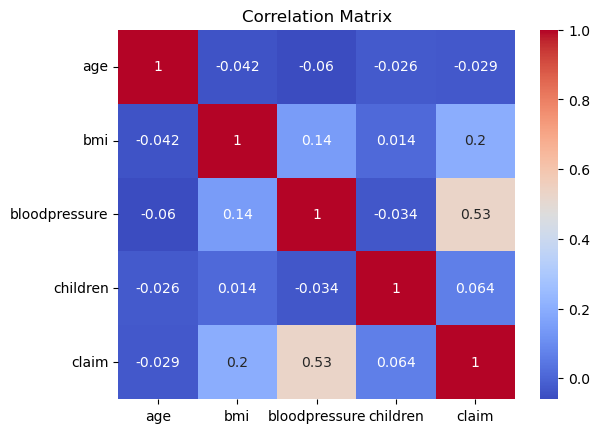

In [10]:
## Correlation Heatmap (numeric features only)
numeric_cols = ['age', 'bmi', 'bloodpressure', 'children', 'claim']
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


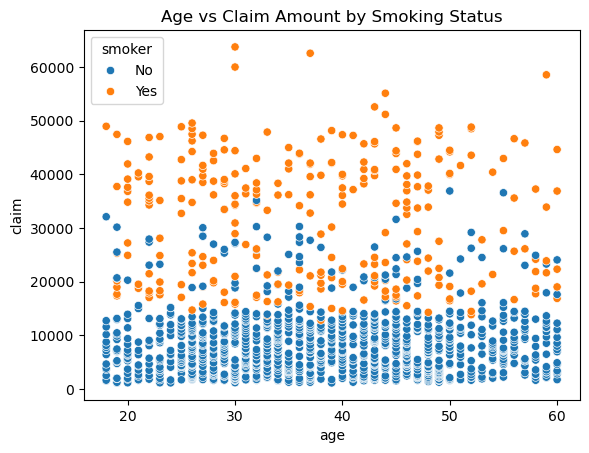

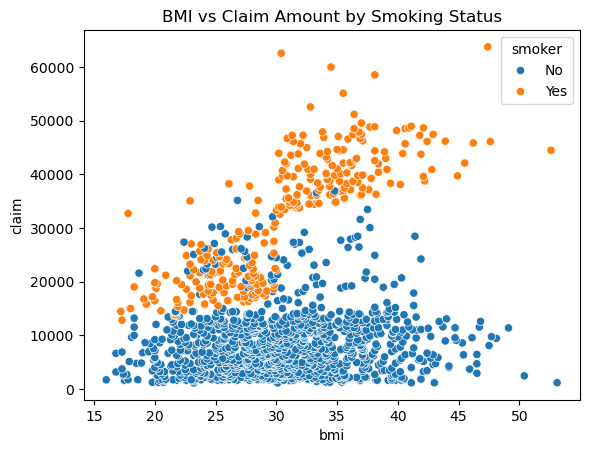

In [11]:
## Scatter Plots for Age and BMI vs Claim
sns.scatterplot(x="age", y="claim", data=data, hue="smoker")
plt.title("Age vs Claim Amount by Smoking Status")
plt.show()

sns.scatterplot(x="bmi", y="claim", data=data, hue="smoker")
plt.title("BMI vs Claim Amount by Smoking Status")
plt.show()


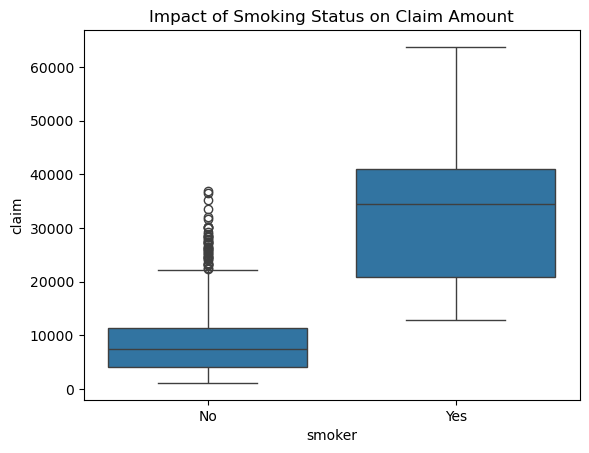

In [12]:
## Box Plot for Smoking Status
sns.boxplot(x="smoker", y="claim", data=data)
plt.title("Impact of Smoking Status on Claim Amount")
plt.show()


## Prepare Data for Linear Regression

In [25]:
## Define Features (X) and Target (y)
X = data.drop("claim", axis=1)
y = data["claim"]


In [27]:
## Encode Categorical Variables
## Categorical columns: gender, smoker, region, diabetic
categorical_features = ["gender", "smoker", "region", "diabetic"]
numeric_features = ["age", "bmi", "bloodpressure", "children"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="passthrough"
)

X_processed = preprocessor.fit_transform(X)


## Split Data into Train and Test Sets

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)


## Train Linear Regression Model

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


## Evaluate Model Performance

In [18]:
## Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")


Mean Absolute Error (MAE): 2961.68


In [19]:
## Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Root Mean Squared Error (RMSE): 4214.56


## Visualize Predictions vs Actual Values

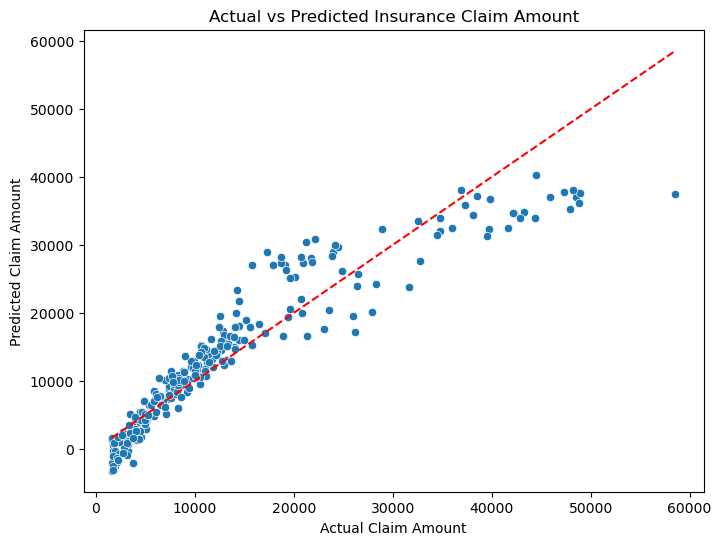

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Claim Amount")
plt.ylabel("Predicted Claim Amount")
plt.title("Actual vs Predicted Insurance Claim Amount")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
plt.show()


## Analyze Feature Importance

In [21]:
# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)


                     Feature   Coefficient
1            cat__smoker_Yes  10253.752049
2      cat__region_northwest   1232.616621
3      cat__region_southeast    998.159792
0           cat__gender_Male    596.771544
4      cat__region_southwest    458.392965
9             remainder__bmi    206.724495
10  remainder__bloodpressure    103.001481
7       remainder__PatientID      9.464404
6           remainder__index      9.464404
8             remainder__age      6.422614
11       remainder__children    -32.643732
5          cat__diabetic_Yes   -355.688156
